# SHAP-Based Patient-Level Explanation of Mortality Risk Predictions

In [1245]:
import joblib
import shap
import pandas as pd
from sklearn.pipeline import Pipeline
import numpy as np
from sklearn.metrics import (confusion_matrix, classification_report)
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib.patches as mpatches

# Load Saved Models and Data

In [1247]:
# We load our best models
best_logistic_model = joblib.load("../machine learning modeling/best_logistic_model.pkl")
best_model_gb = joblib.load("../machine learning modeling/best_gradient_boosting_model.pkl")
X_train = joblib.load("../machine learning modeling/X_train.pkl")
X_test = joblib.load("../machine learning modeling/X_test.pkl")
y_train = joblib.load("../machine learning modeling/y_train.pkl")
y_test = joblib.load("../machine learning modeling/y_test.pkl")

In [1248]:
print(type(best_logistic_model))
print(type(best_model_gb))

<class 'sklearn.pipeline.Pipeline'>
<class 'sklearn.pipeline.Pipeline'>


This shows the saved models are pipeline. So, we double check the pipeline steps.

In [1250]:
if isinstance(best_logistic_model, Pipeline):
    print("Logistic Pipeline Steps:", best_logistic_model.named_steps.keys())

if isinstance(best_model_gb, Pipeline):
    print("Gradient Boosting Pipeline Steps:", best_model_gb.named_steps.keys())

Logistic Pipeline Steps: dict_keys(['preprocessor', 'classifier'])
Gradient Boosting Pipeline Steps: dict_keys(['preprocessor', 'classifier'])


We separate the preprocessing step from the estimator (classifier) so SHAP explainer sees the transformed features that the classifier uses.

In [1252]:
def split_pipeline(model):
    if isinstance(model, Pipeline):
        preprocessor = Pipeline(model.steps[:-1]) # returns everything but the last item in the pipeline
        estimator = model.steps[-1][1]
        return preprocessor, estimator

    return None, model

log_preprocess, log_estimator = split_pipeline(best_logistic_model)
gb_preprocess, gb_estimator = split_pipeline(best_model_gb)

In [1253]:
print(log_estimator)

LogisticRegression(C=0.03, class_weight='balanced', max_iter=1000, penalty='l2',
                   random_state=42)


In [1254]:
print(gb_estimator)

HistGradientBoostingClassifier(class_weight='balanced', early_stopping=True,
                               l2_regularization=np.float64(1.025616274847307),
                               learning_rate=np.float64(0.012502377950801122),
                               max_features=0.6, max_iter=847,
                               max_leaf_nodes=77, n_iter_no_change=20,
                               random_state=42, validation_fraction=0.15)


# Prepare Data for SHAP

We start by defining functions that will help us transform our data

In [1257]:
# After preprocessing, the transformed matrix may be a sparse matrix,
# which is not preferred for ploting, so we convert to dense matrix

def to_dense(X):
    if hasattr(X, "toarray"):        #sparse matrix has method "toarray" attributes
        return X.to_array()         # converts to dense arrays
    return X
        

def get_feature_names(preprocess, X_raw):
    """ We will try to extract the feature names and clean it, and if it fails we resort to default names"""
    try:
        names = preprocess.get_feature_names_out()
    except Exception:
        names = [f"feature_{i}" for i in range(preprocess.transform(X_raw).shape[1])]

    cleaned = []
    for name in names:
        cleaned_name = str(name)
        cleaned_name = cleaned_name.replace("num__", "")
        cleaned_name = cleaned_name.replace("cat__", "")
        cleaned_name = cleaned_name.replace("numeric__","")
        cleaned.append(cleaned_name)
    return cleaned

print(get_feature_names(gb_preprocess, X_train))

['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium', 'anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']


We are now ready to transform our X_train and X_test into a form most compatible for SHAP

## We transform X_test and X_train for logistic regression SHAP explainer

In [1260]:
# We transform X_train and X_test data to be in the same format that our selected models sees them.
if log_preprocess is not None:     # means log_preprocess is in a pipeline
    X_train_log_array = to_dense(log_preprocess.transform(X_train))
    X_test_log_array = to_dense(log_preprocess.transform(X_test))
    log_feature_names = get_feature_names(log_preprocess, X_train)
else:    # we use the original data if not.
    X_train_log_array = X_train.values
    X_test_log_array = X_test.values
    log_feature_names = X_train.columns.tolist()

# We put the transformed data into a data frame for easier ploting using SHAP.

X_train_log = pd.DataFrame(X_train_log_array,
                           columns = log_feature_names,
                           index = X_train.index)

X_test_log = pd.DataFrame(X_test_log_array, columns= log_feature_names, index = X_test.index)
    

In [1261]:
print(X_train_log.shape)
print(X_test_log.shape)

(239, 11)
(60, 11)


## We transform X_test and X_train for gradient boosting SHAP explainer

In [1263]:
if gb_preprocess is not None:
    X_train_gb_array = to_dense(gb_preprocess.transform(X_train))
    X_test_gb_array = to_dense(gb_preprocess.transform(X_test))
    gb_feature_names = get_feature_names(gb_preprocess, X_train)

else:
    X_train_gb_array = X_train.values
    X_test_gb_array = X_test.values
    gb_feature_names = X_train.columns.tolist()


X_train_gb = pd.DataFrame(X_train_gb_array, 
                          columns = gb_feature_names,
                          index= X_train.index)

X_test_gb = pd.DataFrame(X_test_gb_array,
                         columns = gb_feature_names,
                         index = X_test.index)



In [1264]:
print(X_train_gb.shape)
print(X_test_gb.shape)

(239, 11)
(60, 11)


In [1265]:
X_train_gb.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
115,58.0,400.0,40.0,164000.0,1.0,139.0,1.0,0.0,0.0,0.0,0.0
23,53.0,63.0,60.0,368000.0,0.8,135.0,0.0,1.0,0.0,1.0,0.0
0,75.0,582.0,20.0,265000.0,1.9,130.0,0.0,0.0,1.0,1.0,0.0
247,64.0,143.0,25.0,246000.0,2.4,135.0,0.0,0.0,0.0,1.0,0.0
194,45.0,582.0,20.0,126000.0,1.6,135.0,0.0,0.0,1.0,1.0,0.0


In [1266]:
X_test_gb.head()

,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,anaemia,diabetes,high_blood_pressure,sex,smoking
274,60.0,257.0,30.0,150000.0,1.0,137.0,1.0,1.0,0.0,1.0,1.0
149,60.0,2261.0,35.0,228000.0,0.9,136.0,0.0,0.0,1.0,1.0,0.0
120,60.0,737.0,60.0,210000.0,1.5,135.0,1.0,0.0,1.0,1.0,1.0
226,58.0,57.0,25.0,189000.0,1.3,132.0,1.0,0.0,0.0,1.0,1.0
125,43.0,358.0,50.0,237000.0,1.3,135.0,1.0,0.0,0.0,0.0,0.0


# Re-Evaluate the Selected Models Performance before Explaining their Predictions using SHAP

In [1268]:
def evaluate_model(model, X_test_raw, y_test, label):
    y_test_pred = model.predict(X_test_raw)
    if hasattr(model, "predict_proba"):
        y_test_prob = model.predict_proba(X_test_raw)[:,1]

    else:
        y_test_prob = np.repeat(np.nan, len(y_test))

    print(f"\n======================{label}===========================================")
    print(confusion_matrix(y_test, y_test_pred))
    print(classification_report(y_test, y_test_pred, target_names=["no_death_event", "death_event"], zero_division=0))
    
    return pd.DataFrame({"actual":y_test, "predicted": y_test_pred,
                         "proba_death": y_test_prob}, index= X_test_raw.index).head(10)
    

In [1269]:
log_results = evaluate_model(best_logistic_model, X_test, y_test, "Tuned Logistic Regression")
log_results


======================Tuned Logistic Regression===========================================
[[32  9]
 [ 5 14]]
                precision    recall  f1-score   support

no_death_event       0.86      0.78      0.82        41
   death_event       0.61      0.74      0.67        19

      accuracy                           0.77        60
     macro avg       0.74      0.76      0.74        60
  weighted avg       0.78      0.77      0.77        60



,actual,predicted,proba_death
274,0,1,0.515578
149,0,0,0.499491
120,0,0,0.346857
226,0,1,0.577249
125,0,0,0.277612
298,0,0,0.317515
130,0,0,0.258148
110,1,0,0.389353
275,0,0,0.308861
190,0,1,0.654949


In [1270]:
gb_results = evaluate_model(best_model_gb, X_test, y_test, "Tuned Gradient Boosting")
gb_results


======================Tuned Gradient Boosting===========================================
[[31 10]
 [ 5 14]]
                precision    recall  f1-score   support

no_death_event       0.86      0.76      0.81        41
   death_event       0.58      0.74      0.65        19

      accuracy                           0.75        60
     macro avg       0.72      0.75      0.73        60
  weighted avg       0.77      0.75      0.76        60



,actual,predicted,proba_death
274,0,0,0.467760
149,0,0,0.176152
120,0,0,0.473181
226,0,1,0.797141
125,0,0,0.232733
298,0,1,0.558085
130,0,0,0.206276
110,1,1,0.535558
275,0,0,0.228248
190,0,1,0.863857


# We Build SHAP Explainer for the Logistic Regression Model

In [1272]:
# we create a representative background sample. We can actually use the whole training set since our dataset is small

log_background = X_train_log

In [1273]:
log_explainer = shap.LinearExplainer(log_estimator, log_background)

Background dataset has 239 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=239 when initializing the masker.


In [1274]:
log_exp = log_explainer(X_test_log)
log_exp.values.shape

(60, 11)

We now focus on explaining log_estimator's prediction on death event class (class 1) using SHAP

In [1276]:
# we define this just incase our explainer is 3 dimensional (in our case is not)

def postive_class_explanation(exp, class_index):
    if len(exp.values.shape) == 3:  # (no of patients, no of features, no of classes); 3 dimension
        return exp[:,:, class_index]
    return exp   # this returns the logodds of class 1

log_exp_death = postive_class_explanation(log_exp, class_index = 1)  
log_exp_death.values.shape

(60, 11)

## Logistic regression model global feature importance using SHAP

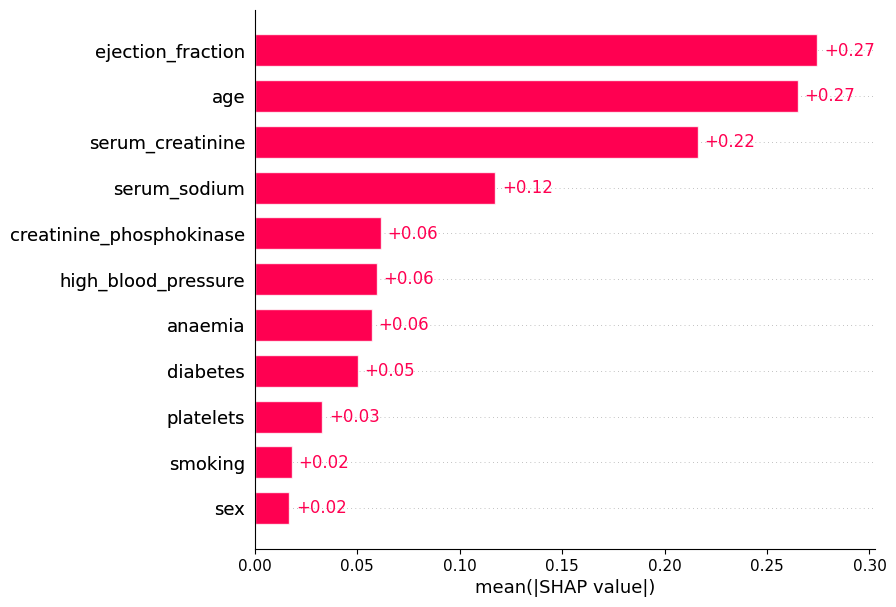

<Figure size 640x480 with 0 Axes>

In [1278]:
fig_dir = Path("..")/"figures"
fig_dir.mkdir(exist_ok=True)
shap.plots.bar(log_exp_death, max_display=12)
plt.tight_layout()
plt.savefig(fig_dir/"log_global_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

The global shap bar plot for the Logistic Regression model shows that ejection fraction, patients age, and serum_creatine were the most influential features in the model's mortality risk predictions. This shows that the model relied heavily most heavily on heart pumping functions, patient age, and kidney-function-related information when estimating patient's death-event risk. Serum sodium also has moderate contribution while the remaining features had mild effects.

## Logistic regression model global feature importance using SHAP beeswarm plot

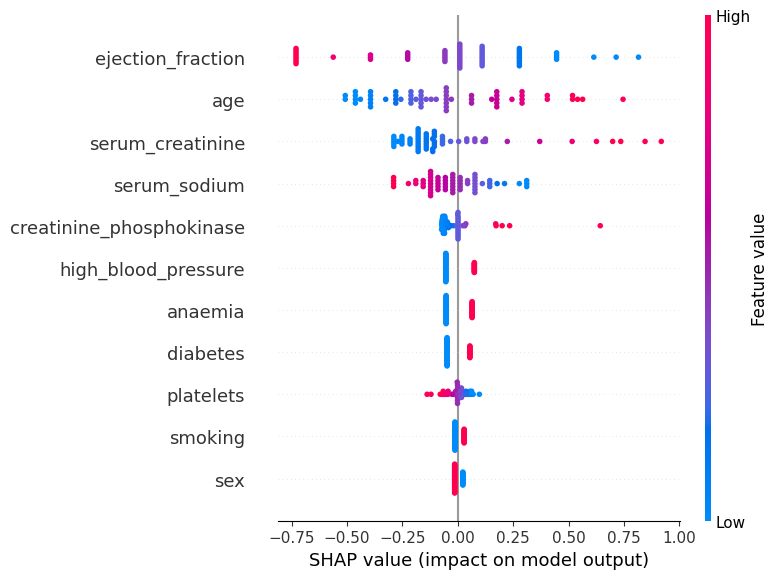

In [1281]:
fig_dir = Path("..")/"figures"
fig_dir.mkdir(exist_ok=True)

shap.plots.beeswarm(log_exp_death, max_display =12, show = False)
plt.tight_layout()
plt.savefig(fig_dir/"log_global_feature_importance_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

The beeswarm plot shows that low ejection fraction appears more on the right, meaning that they push the model toward predicting death event. Also higher ejection fraction also appeared on the left, meaning that higher ejection fraction tends to push the model away from predicting death event.
On the other hand, higher age and higher serum creatine appeared more on the right, which means that higher age and higher values of serum creatine pushes the model to predict death event. Lower age and lower serum creatinine appeared on the left, meaning that they tend to push the model's prediction away from death event class. 

## Logistic regression patient level SHAP waterfall plot

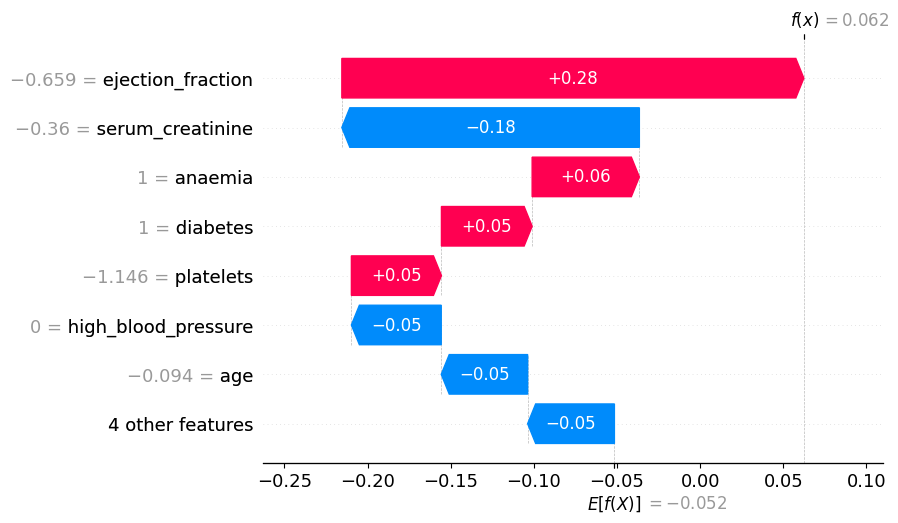

In [1284]:
patient_pos = 0
shap.plots.waterfall(log_exp_death[patient_pos], max_display = 8)

The waterfall plot shows the main factors that influenced the logistic regression model’s prediction for patient 0. Features such as ejection fraction, anaemia status, diabetes status, platelet count, and smoking habit increased the model’s prediction toward the death event class. On the other hand, serum creatinine, high blood pressure, age, and creatinine phosphokinase decreased the model’s prediction, pushing it away from the death event class.

# We Build SHAP Explainer for the Gradient Boosting Model 

In [1287]:
gb_background = X_train_gb.sample(n= min(100, len(X_train_gb)), random_state = 42)


In [1288]:
try:
    gb_explainer = shap.TreeExplainer(gb_estimator, data= gb_background, model_output= "probability")
    gb_exp = gb_explainer(X_test_gb)

except Exception as e:
    """if probability fails we resort to raw explanation """
    print("Probability explanation failed. Resorting to raw explanation")
    print(e)
    gb_explainer = shap.TreeExplainer(gb_estimator, data = gb_background, model_output = "raw")
    gb_exp = gb_explainer(X_test_gb)
    
print(gb_exp.values.shape)

(60, 11)


In [1289]:
gb_exp_death = postive_class_explanation(gb_exp, class_index = 1)
print(gb_exp_death.values.shape)

(60, 11)


## Gradient boosting model global feature importance using SHAP

We visualize top most influential features driving the gradient boosting model's prediction

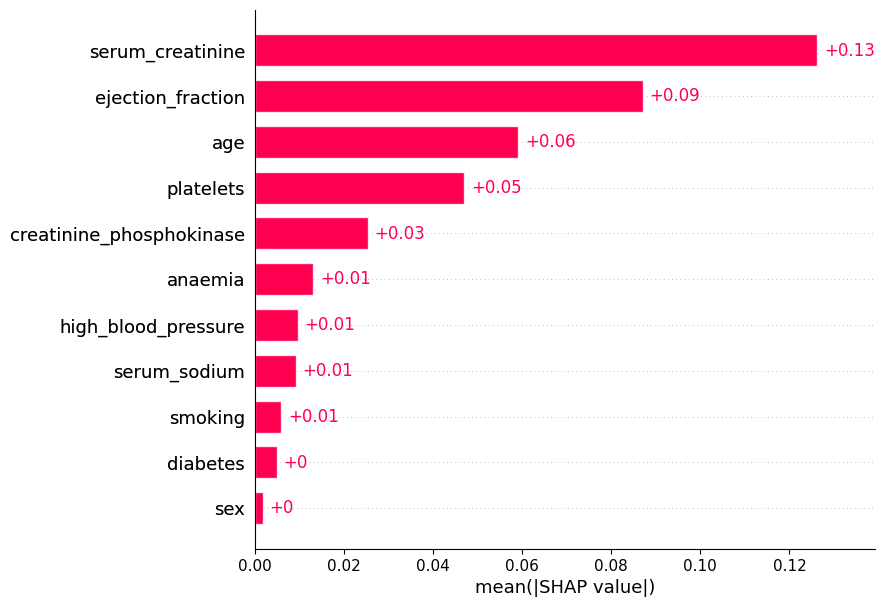

<Figure size 640x480 with 0 Axes>

In [1292]:
fig_dir = Path("..")/"figures"
fig_dir.mkdir(exist_ok=True)
shap.plots.bar(gb_exp_death, max_display=12)
plt.tight_layout()
plt.savefig(fig_dir/"gb_global_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Gradient Boosting model global feature importance using SHAP beeswarm plot

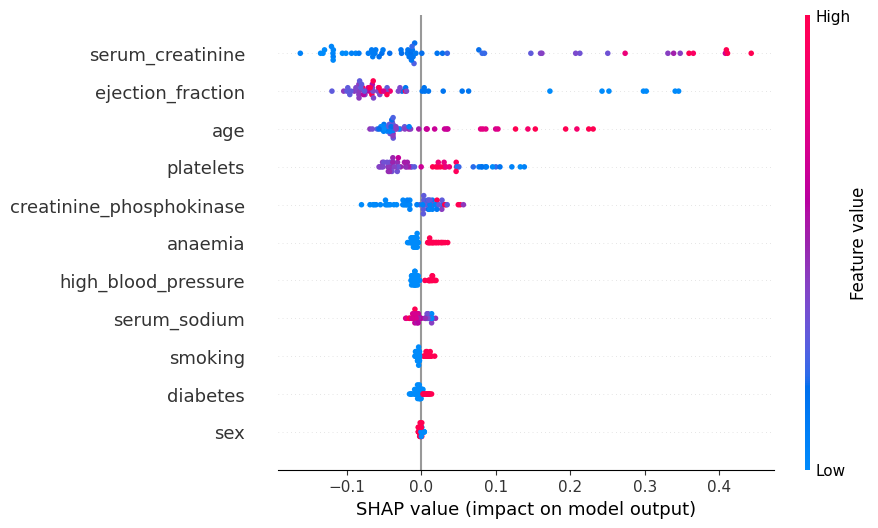

<Figure size 640x480 with 0 Axes>

In [1294]:
fig_dir = Path("..")/"figures"
fig_dir.mkdir(exist_ok=True)
shap.plots.beeswarm(gb_exp_death, max_display=12)
plt.tight_layout()
plt.savefig(fig_dir/"gb_global_feature_importance_beeswarm.png", dpi=300, bbox_inches="tight")
plt.show()

## Gradient boosting patient level explanation using SHAP waterfall plot

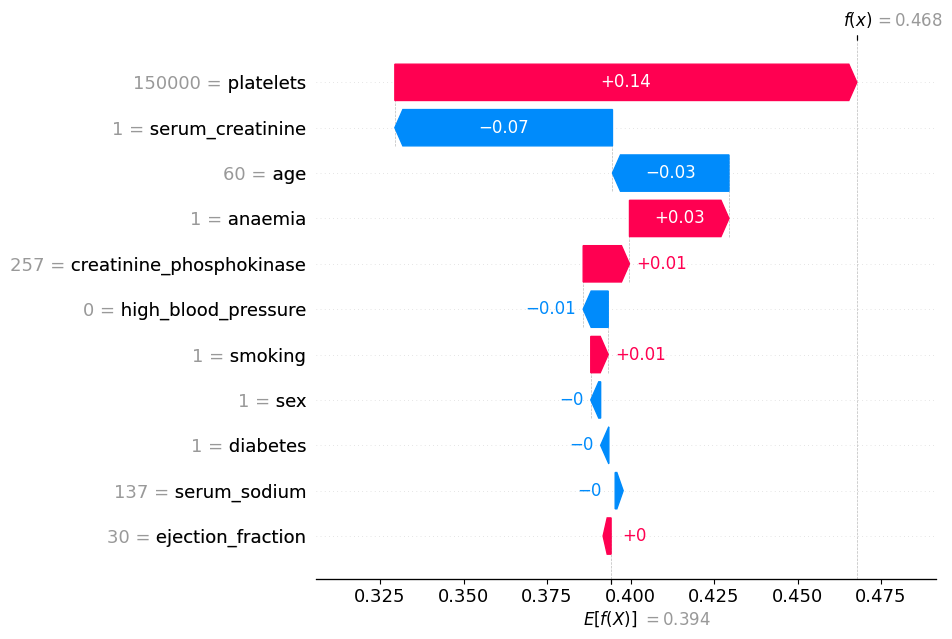

In [1296]:
patient_pos = 0
shap.plots.waterfall(gb_exp_death[patient_pos], max_display =12)

# We Select Specific TP, TN, FP, and FN Patients for Comprehensive  SHAP Explanation Summary

In [1298]:
def add_case_type(result):
    df = result.copy()
    conditions = [(df["actual"]==1) & (df["predicted"]==1),
                 (df["actual"]==0) & (df["predicted"] ==0), 
                 (df["actual"]==0) & (df["predicted"]==1), 
                 (df["actual"]==1) & (df["predicted"]==0)]
    labels = ["TP", "TN", "FP", "FN"]
    df["case_type"] = np.select(conditions, labels, default="other")
    return df

gb_result_cases = add_case_type(gb_results)
log_result_cases = add_case_type(log_results)
log_result_cases.head()

,actual,predicted,proba_death,case_type
274,0,1,0.515578,FP
149,0,0,0.499491,TN
120,0,0,0.346857,TN
226,0,1,0.577249,FP
125,0,0,0.277612,TN


In [1299]:
gb_result_cases.head()

,actual,predicted,proba_death,case_type
274,0,0,0.467760,TN
149,0,0,0.176152,TN
120,0,0,0.473181,TN
226,0,1,0.797141,FP
125,0,0,0.232733,TN


We select one student from each group for a more comprehensive explanation

In [1301]:
def pick_patient(results, case_type, prefer ="highest_risk"):
    subset =results[results["case_type"]==case_type].copy()
    if subset.empty:
        print(f"no {case_type} found!")
        return None

    if prefer =="highest_risk":
        return subset.sort_values("proba_death", ascending=False).index[0]

    elif prefer =="lowest_risk":
        return subset.sort_values("proba_death", ascending=True).index[0]

    else:
        return subset.index[0]

tp_id = pick_patient(gb_result_cases, "TP", "highest_risk")
tn_id = pick_patient(gb_result_cases, "TN", "lowest_risk")
fp_id = pick_patient(gb_result_cases, "FP", "highest_risk")
fn_id = pick_patient(gb_result_cases, "FN", "lowest_risk")

        

no FN found!


In [1302]:
print(tp_id, tn_id, fp_id, fn_id)

110 149 190 None


# We Build Patient Level SHAP Explanations for the Selected Patients

In [1304]:
# Given a known index from the test set, this extraxcts its position in the SHAP object
def patient_position(patient_id, X_test_df):
    return X_test_df.index.get_loc(patient_id)


In [1305]:
# This function will give top features contributors for a specific patient with a known position
def top_patient_shap(exp, patient_pos, top_n = 8):
    vals = exp.values[patient_pos]
    data_vals = exp.data[patient_pos]
    names = exp.feature_names
    out = pd.DataFrame({"feature": names,
                        "feature_value": data_vals,
                        "shap_values": vals, })
    out["direction"] = np.where(out["shap_values"] > 0,
    "increase predicted death-event risk", "decreases predicted death-event risk")
    out["abs_shap"] = out["shap_values"].abs()
    return out.sort_values("abs_shap", ascending= False).head(8)
    

## We provide a detailed SHAP explanation for the TP patient

In [1307]:
# Detailed gradient boosting model explanation for patient with patient_id = tp_id
patient_id = tp_id
patient_pos = patient_position(patient_id, X_test_gb)
print(gb_result_cases.loc[patient_id])

actual                1
predicted             1
proba_death    0.535558
case_type            TP
Name: 110, dtype: object


In [1308]:
# Detailed SHAP explanation for patient with patient_id = tp_id
top_patient_shap(gb_exp_death, patient_pos,top_n = 8)

,feature,feature_value,shap_values,direction,abs_shap
0,age,85.0,0.224807,increase predicted death-event risk,0.224807
2,ejection_fraction,60.0,-0.066397,decreases predicted death-event risk,0.066397
3,platelets,306000.0,-0.030847,decreases predicted death-event risk,0.030847
4,serum_creatinine,1.2,0.028421,increase predicted death-event risk,0.028421
10,smoking,1.0,0.017956,increase predicted death-event risk,0.017956
1,creatinine_phosphokinase,129.0,-0.015547,decreases predicted death-event risk,0.015547
5,serum_sodium,132.0,0.015329,increase predicted death-event risk,0.015329
7,diabetes,0.0,-0.014314,decreases predicted death-event risk,0.014314


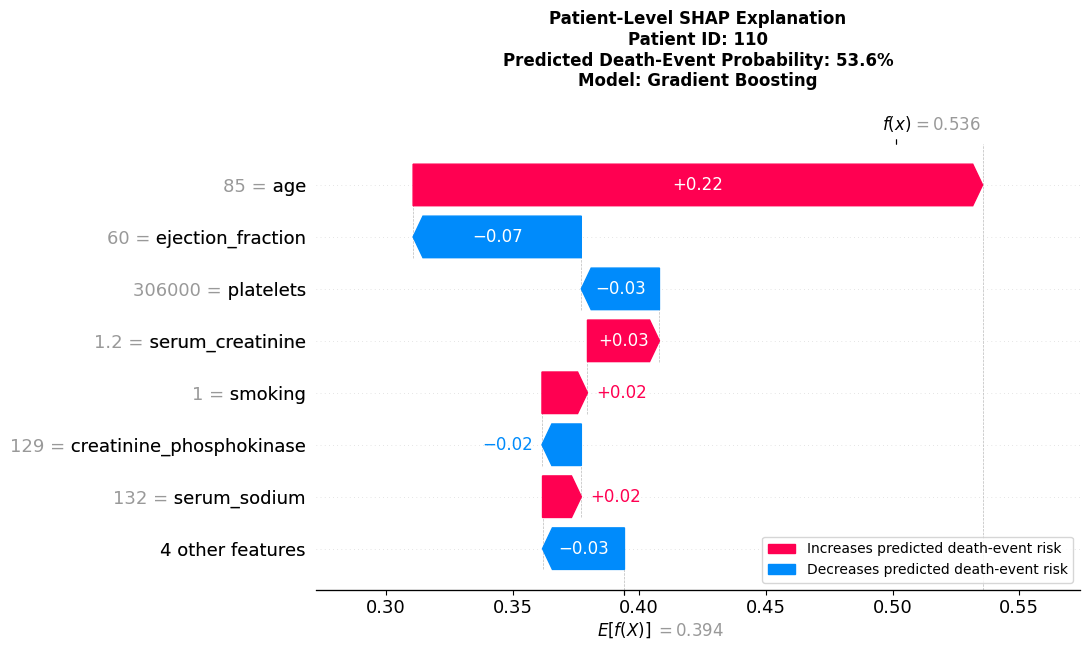

In [1309]:
# We plot and save the waterfall plot for patient with patient_id = tp_id
fig_dir = Path("..")/"figures"
fig_dir.mkdir(exist_ok=True)
patient_id = tp_id
prob_death = gb_result_cases.loc[patient_id, "proba_death"]
patient_pos = patient_position(patient_id, X_test_gb)
shap.plots.waterfall(gb_exp_death[patient_pos], max_display=8,show=False)
fig = plt.gcf()
fig.set_size_inches(11,6.6)
ax = plt.gca()
ax.set_xlim(0.27, 0.62)
plt.title(f"Patient-Level SHAP Explanation\n"
          f"Patient ID: {tp_id}\n"
f"Predicted Death-Event Probability: {prob_death:.1%}\n"
f"Model: Gradient Boosting", fontsize=12, fontweight="bold", pad=20)

# Manual legend
red_patch = mpatches.Patch(
    color="#ff0051",
    label="Increases predicted death-event risk"
)

blue_patch = mpatches.Patch(
    color="#008bfb",
    label="Decreases predicted death-event risk"
)

ax.legend(
    handles=[red_patch, blue_patch],
    loc="lower right",
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.savefig(fig_dir/"gb_waterfall_true_positive.png", dpi=300, bbox_inches="tight")
plt.show()

Patient 110 had an actual death event outcome. The Gradient Boosting model predicted death event with probability of 54%.
The SHAP explanation indicates tha age, serum creatinine, and smoking contributed most strongly toward higher predicted mortality risk for this patient. In contrast, ejection fraction, platelets, and creatinine phosphokinase pushed the prediction away from death-event class.

## We provide a detailed SHAP explanation for the TN patient

We conduct a SHAP explanation summary for a patient with a true negative

In [1313]:
# Detailed gradient boosting model explanation for patient with patient_id = tn_id
patient_id = tn_id
patient_pos = patient_position(patient_id, X_test_gb)
print(gb_result_cases.loc[patient_id])

actual                0
predicted             0
proba_death    0.176152
case_type            TN
Name: 149, dtype: object


In [1314]:
# Detailed SHAP explanation for patient with patient_id = tn_id
top_patient_shap(gb_exp_death, patient_pos,top_n = 8)

,feature,feature_value,shap_values,direction,abs_shap
4,serum_creatinine,0.9,-0.093646,decreases predicted death-event risk,0.093646
2,ejection_fraction,35.0,-0.081175,decreases predicted death-event risk,0.081175
3,platelets,228000.0,-0.053197,decreases predicted death-event risk,0.053197
1,creatinine_phosphokinase,2261.0,0.049629,increase predicted death-event risk,0.049629
0,age,60.0,-0.038043,decreases predicted death-event risk,0.038043
8,high_blood_pressure,1.0,0.010259,increase predicted death-event risk,0.010259
6,anaemia,0.0,-0.007856,decreases predicted death-event risk,0.007856
10,smoking,0.0,-0.007508,decreases predicted death-event risk,0.007508


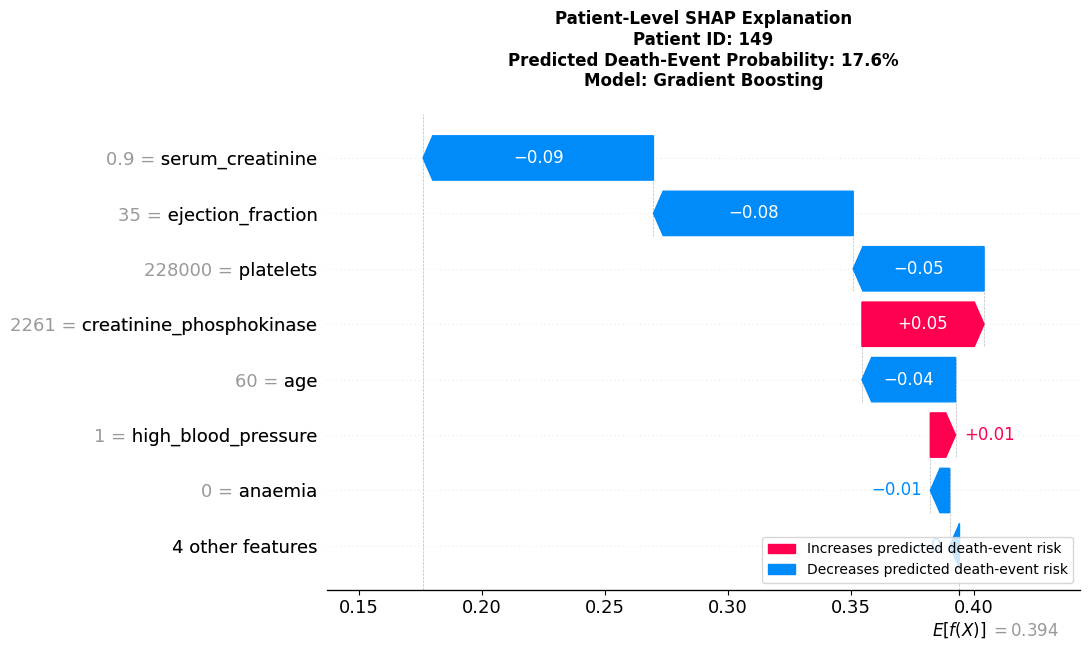

In [1315]:
# We plot and save the waterfall plot for patient with patient_id = tn_id
fig_dir = Path("..")/"figures"
fig_dir.mkdir(exist_ok=True)
patient_id = tn_id
prob_death = gb_result_cases.loc[patient_id, "proba_death"]
patient_pos = patient_position(patient_id, X_test_gb)
shap.plots.waterfall(gb_exp_death[patient_pos], max_display=8,show=False)
fig = plt.gcf()
fig.set_size_inches(11,6.6)
ax = plt.gca()
ax.set_xlim(0.27, 0.62)
plt.title(f"Patient-Level SHAP Explanation\n"
          f"Patient ID: {tn_id}\n"
f"Predicted Death-Event Probability: {prob_death:.1%}\n"
f"Model: Gradient Boosting", fontsize=12, fontweight="bold", pad=20)

# Manual legend
red_patch = mpatches.Patch(
    color="#ff0051",
    label="Increases predicted death-event risk"
)

blue_patch = mpatches.Patch(
    color="#008bfb",
    label="Decreases predicted death-event risk"
)

ax.legend(
    handles=[red_patch, blue_patch],
    loc="lower right",
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.savefig(fig_dir/"gb_waterfall_true_negative.png", dpi=300, bbox_inches="tight")
plt.show()

Patient 149 had an actual no-death event outcome. The Gradient Boosting model predicted no-death event with probability of 18%.
The SHAP explanation indicates tha creatinine phosphokinase and high blood pressure contributed most strongly toward higher predicted mortality risk for this patient. In contrast, serum creatinine, ejection fraction, platelet, and age pushed the prediction away from death-event class.

## We provide a detailed SHAP explanation for the FP patient

We conduct a SHAP explanation summary for a patient with a false positive

In [1319]:
# Detailed gradient boosting model explanation for patient with patient_id = fp_id
patient_id = fp_id
patient_pos = patient_position(patient_id, X_test_gb)
print(gb_result_cases.loc[patient_id])

actual                0
predicted             1
proba_death    0.863857
case_type            FP
Name: 190, dtype: object


In [1320]:
# Detailed SHAP explanation for patient with patient_id = fp_id
top_patient_shap(gb_exp_death, patient_pos,top_n = 8)

,feature,feature_value,shap_values,direction,abs_shap
4,serum_creatinine,2.1,0.338810,increase predicted death-event risk,0.338810
0,age,80.0,0.143109,increase predicted death-event risk,0.143109
2,ejection_fraction,35.0,-0.045946,decreases predicted death-event risk,0.045946
3,platelets,350000.0,0.030618,increase predicted death-event risk,0.030618
1,creatinine_phosphokinase,582.0,0.008073,increase predicted death-event risk,0.008073
5,serum_sodium,134.0,0.007758,increase predicted death-event risk,0.007758
6,anaemia,0.0,-0.006198,decreases predicted death-event risk,0.006198
8,high_blood_pressure,0.0,-0.005996,decreases predicted death-event risk,0.005996


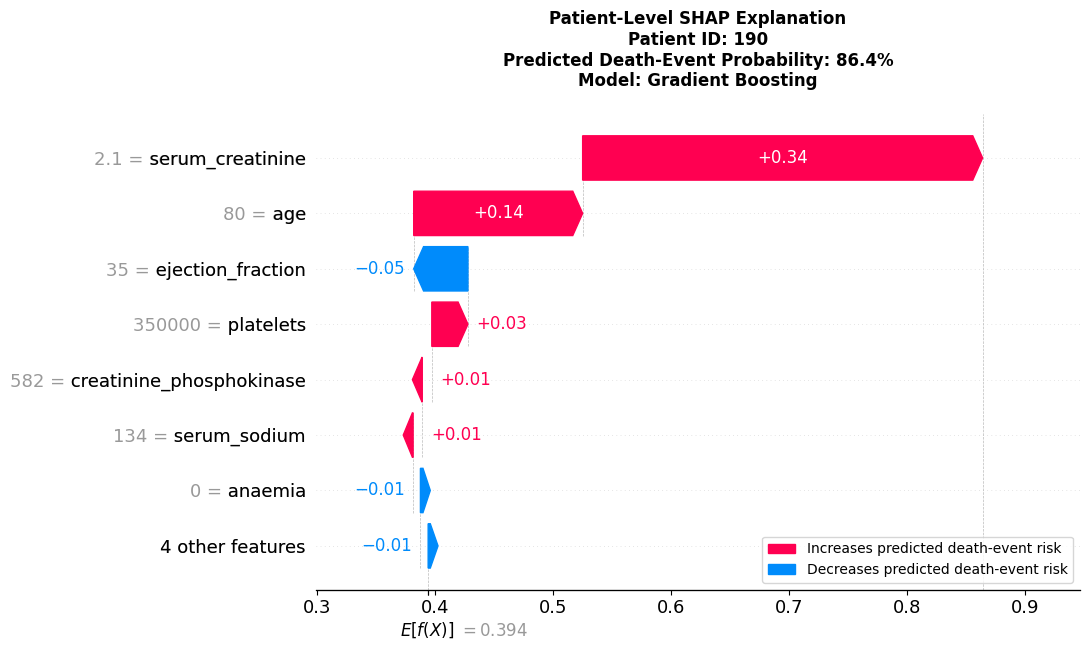

In [1321]:
# We plot and save the waterfall plot for patient with patient_id = fp_id
fig_dir = Path("..")/"figures"
fig_dir.mkdir(exist_ok=True)
patient_id = fp_id
prob_death = gb_result_cases.loc[patient_id, "proba_death"]
patient_pos = patient_position(patient_id, X_test_gb)
shap.plots.waterfall(gb_exp_death[patient_pos], max_display=8,show=False)
fig = plt.gcf()
fig.set_size_inches(11,6.6)
ax = plt.gca()
ax.set_xlim(0.27, 0.62)
plt.title(f"Patient-Level SHAP Explanation\n"
          f"Patient ID: {fp_id}\n"
f"Predicted Death-Event Probability: {prob_death:.1%}\n"
f"Model: Gradient Boosting", fontsize=12, fontweight="bold", pad=20)

# Manual legend
red_patch = mpatches.Patch(
    color="#ff0051",
    label="Increases predicted death-event risk"
)

blue_patch = mpatches.Patch(
    color="#008bfb",
    label="Decreases predicted death-event risk"
)

ax.legend(
    handles=[red_patch, blue_patch],
    loc="lower right",
    frameon=True,
    fontsize=10
)

plt.tight_layout()
plt.savefig(fig_dir/"gb_waterfall_false_positive.png", dpi=300, bbox_inches="tight")
plt.show()

Patient 190 had an actual no-death event outcome. The Gradient Boosting model predicted death event with probability of 86.4%.
The SHAP explanation indicates tha serum creatinine and age contributed most strongly toward higher predicted mortality risk for this patient. In contrast, ejection fraction and the patinet non-anaemic condition pushed the prediction away from death-event class.

# We compare Logistic Regression and Gradient Boosting Overall Features Contributions

In [1324]:
def global_shap_importance(exp, model_name, top_n=12):
    importance = np.abs(exp.values).mean(axis=0)
    df =pd.DataFrame({"feature": exp.feature_names,
                      "mean_abs_shap": importance,
                      "model": model_name})
    return df.sort_values("mean_abs_shap", ascending=False).head(top_n)

log_importance = global_shap_importance(log_exp_death, "Logistic Regression")
gb_importance = global_shap_importance(gb_exp_death, "Gradient Boosting")


In [1325]:
log_importance

,feature,mean_abs_shap,model
2,ejection_fraction,0.274485,Logistic Regression
0,age,0.265082,Logistic Regression
4,serum_creatinine,0.216147,Logistic Regression
5,serum_sodium,0.117428,Logistic Regression
1,creatinine_phosphokinase,0.061355,Logistic Regression
8,high_blood_pressure,0.059510,Logistic Regression
6,anaemia,0.057038,Logistic Regression
7,diabetes,0.050214,Logistic Regression
3,platelets,0.032883,Logistic Regression
10,smoking,0.018073,Logistic Regression


In [1326]:
gb_importance

,feature,mean_abs_shap,model
4,serum_creatinine,0.126227,Gradient Boosting
2,ejection_fraction,0.087043,Gradient Boosting
0,age,0.059106,Gradient Boosting
3,platelets,0.046998,Gradient Boosting
1,creatinine_phosphokinase,0.025395,Gradient Boosting
6,anaemia,0.013118,Gradient Boosting
8,high_blood_pressure,0.009670,Gradient Boosting
5,serum_sodium,0.009135,Gradient Boosting
10,smoking,0.005945,Gradient Boosting
7,diabetes,0.004916,Gradient Boosting


The two tables compares the most influential features within each model. Both models rank ejection fraction, serum creatinine, and age as the largest average SHAP contributors. Also note that the logistic regression model output is in logodds while the gradient boosting model's output is in probability.